In [88]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU device list:", tf.config.list_physical_devices('GPU'))


Num GPUs Available:  2
GPU device list: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [89]:
pip show nvidia-cudnn-cu13


Note: you may need to restart the kernel to use updated packages.


In [90]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("cuDNN version:", torch.backends.cudnn.version())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: True
cuDNN version: 90300
GPU name: Tesla T4


In [91]:
!where cudnn64_9.dll

/bin/bash: line 1: where: command not found


In [92]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuDNN available:", torch.backends.cudnn.is_available())
    print("cuDNN version:", torch.backends.cudnn.version())
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("cuDNN available: False")
    print("cuDNN version: N/A")
    print("GPU name: No GPU")

CUDA available: True
cuDNN available: True
cuDNN version: 90300
GPU name: Tesla T4


In [93]:
import torch
x = torch.rand(10000, 10000).cuda()
y = torch.mm(x, x)
print("Computation done on:", "GPU" if x.is_cuda else "CPU")


Computation done on: GPU


In [94]:
torch.backends.cudnn.benchmark = True


In [95]:
import kagglehub
path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/trip-advisor-hotel-reviews


In [96]:
!pip install pandas

In [97]:
import pandas as pd
import os

data_path = path
file_name = "tripadvisor_hotel_reviews.csv"
full_path = os.path.join(data_path, file_name)

df = pd.read_csv(full_path)

display(df.head())
display(df.info())

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


None

## Explore and Visualize the data

### Subtask:
Visualize the distribution of ratings in the dataset.

In [98]:
!pip install matplotlib seaborn

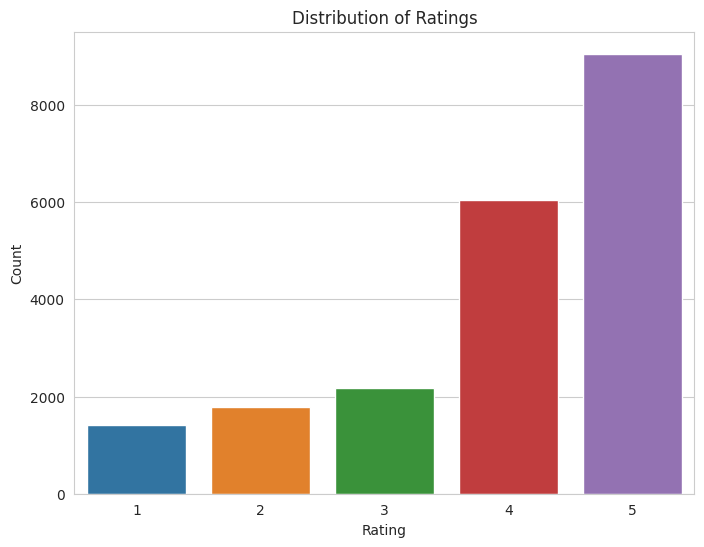

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Rating', data=df)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## Balance the dataset

### Subtask:
Create a balanced sample of 7000 reviews.

In [100]:
total_samples = 7000
num_ratings = df['Rating'].nunique()
samples_per_rating = total_samples // num_ratings
balanced_df = df.groupby('Rating').apply(lambda x: x.sample(n=samples_per_rating, random_state=42)).reset_index(drop=True)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

display(balanced_df.head())
display(balanced_df['Rating'].value_counts())

/tmp/ipykernel_46/1711939760.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Rating').apply(lambda x: x.sample(n=samples_per_rating, random_state=42)).reset_index(drop=True)


,Review,Rating
0,excellent hotel excellent value great location...,5
1,good comfortable not great stayed comfort suit...,3
2,over-priced efficient wife just returned week ...,2
3,"beware, spare sanity money, puerto rico better...",1
4,good slightly town hotel hotel beautiful build...,4


Rating
5    1400
3    1400
2    1400
1    1400
4    1400
Name: count, dtype: int64

In [101]:
import re
from transformers import BertTokenizer
import torch
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

balanced_df['Cleaned_Review'] = balanced_df['Review'].apply(preprocess_text)
tokenized_reviews = balanced_df['Cleaned_Review'].apply(lambda x: tokenizer.encode_plus(
    text=x,
    add_special_tokens=True,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt',
))
input_ids = torch.cat([item['input_ids'] for item in tokenized_reviews], dim=0)
attention_masks = torch.cat([item['attention_mask'] for item in tokenized_reviews], dim=0)
labels = torch.tensor(balanced_df['Rating'].values)
print("Input IDs shape:", input_ids.shape)
print("Attention Masks shape:", attention_masks.shape)
print("Labels shape:", labels.shape)

Input IDs shape: torch.Size([7000, 128])
Attention Masks shape: torch.Size([7000, 128])
Labels shape: torch.Size([7000])


In [102]:
!pip install pyswarms

In [103]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import time
import pyswarms as ps

In [104]:
input_ids_np = input_ids.numpy()
attention_masks_np = attention_masks.numpy()
labels_np = labels.numpy() - 1

In [105]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    input_ids_np, labels_np, test_size=0.3, random_state=42, stratify=labels_np
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (4900, 128)
Validation shape: (1050, 128)
Test shape: (1050, 128)


In [106]:
vocab_size = 30522
embedding_dim = 64
max_length = 128
num_classes = len(np.unique(labels_np))

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=False)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.build(input_shape=(None, max_length))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_160"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_160 (Embedding)       │ (None, 128, 64)        │     1,953,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_160               │ (None, 128)            │        49,920 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_161 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_320 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_162 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_321 (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,011,909 (7.67 MB)

 Trainable params: 2,011,909 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

In [107]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=64,
    verbose=1
)
end_time = time.time()
runtime_minutes = (end_time - start_time) / 60
best_val_loss = min(history.history['val_loss'])
best_val_acc = max(history.history['val_accuracy'])
results_df = pd.DataFrame([{
    "Best_Val_Loss": best_val_loss,
    "Val_Accuracy": best_val_acc,
    "Runtime_Minutes": runtime_minutes
}])

results_df.to_csv("base_model_results.csv", index=False)

print("\n✅ Results saved to base_model_results.csv")
print(results_df)

Epoch 1/3
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2260 - loss: 1.6084 - val_accuracy: 0.2408 - val_loss: 1.6050
Epoch 2/3
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2774 - loss: 1.6010 - val_accuracy: 0.3592 - val_loss: 1.5875
Epoch 3/3
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3924 - loss: 1.5672 - val_accuracy: 0.4429 - val_loss: 1.4451

✅ Results saved to base_model_results.csv
   Best_Val_Loss  Val_Accuracy  Runtime_Minutes
0        1.44512      0.442857          0.08849


In [108]:
from sklearn.metrics import classification_report
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4329 - loss: 1.4398

Test Accuracy: 42.57%
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.83      0.57       210
           1       0.26      0.22      0.24       210
           2       0.50      0.09      0.15       210
           3       0.39      0.52      0.45       210
           4       0.64      0.46      0.54       210

    accuracy                           0.43      1050
   macro avg       0.45      0.43      0.39      1050
weighted avg       0.45      0.43      0.39      1050



In [109]:
!pip install pyswarms tensorflow pandas numpy scikit-learn


In [110]:
def build_model(params):
    embedding_dim, gru_units, dropout_rate, lr = params
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=int(embedding_dim), input_length=max_length),
        Bidirectional(GRU(int(gru_units), return_sequences=False)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [111]:
def objective_function(x):
    losses = []
    for i, params in enumerate(x):
        embedding_dim, gru_units, dropout_rate, lr = params
        model = build_model(params)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=1,
            batch_size=128,
            verbose=0
        )

        val_loss = history.history['val_loss'][-1]
        losses.append(val_loss)
    return np.array(losses)


In [112]:
bounds = ([32, 32, 0.1, 1e-5], [128, 128, 0.5, 5e-3])

In [113]:
optimizer = ps.single.GlobalBestPSO(
    n_particles=6,
    dimensions=4,
    options={'c1': 1.5, 'c2': 1.5, 'w': 0.7},
    bounds=bounds
)

In [114]:
start_time = time.time()
best_cost, best_pos = optimizer.optimize(objective_function, iters=5)
end_time = time.time()

2025-12-21 03:01:21,355 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best:   0%|          |0/5/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
pyswarms.single.global_best: 100%|██████████|5/5, best_cost=1.13
2025-12-21 03:03:13,229 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 1.1281827688217163, best pos: [6.85006524e+01 6.65766947e+01 4.49461844e-01 4.68770316e-03]


In [115]:
print("\n✅ Best parameters found:")
print(f"Embedding dim: {best_pos[0]:.0f}")
print(f"GRU units: {best_pos[1]:.0f}")
print(f"Dropout: {best_pos[2]:.3f}")
print(f"Learning rate: {best_pos[3]:.6f}")
print(f"Validation loss: {best_cost:.4f}")
print(f"Total time: {(end_time - start_time)/60:.2f} minutes")



✅ Best parameters found:
Embedding dim: 69
GRU units: 67
Dropout: 0.449
Learning rate: 0.004688
Validation loss: 1.1282
Total time: 1.86 minutes


In [116]:
best_model = build_model(best_pos)
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)
y_pred = np.argmax(best_model.predict(X_val), axis=1)
val_acc = accuracy_score(y_val, y_pred)

results = {
    'Best_Embedding_Dim': int(best_pos[0]),
    'Best_GRU_Units': int(best_pos[1]),
    'Best_Dropout': best_pos[2],
    'Best_Learning_Rate': best_pos[3],
    'Best_Val_Loss': best_cost,
    'Val_Accuracy': val_acc
}

# Save results
results_df = pd.DataFrame([results])
results_df.to_csv("pso_results.csv", index=False)

print("\n📁 Results saved to pso_results.csv")
print(results_df)

Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2812 - loss: 1.5262 - val_accuracy: 0.4990 - val_loss: 1.1668
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5440 - loss: 1.0532 - val_accuracy: 0.5238 - val_loss: 1.1026
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7084 - loss: 0.7593 - val_accuracy: 0.5029 - val_loss: 1.2465
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

📁 Results saved to pso_results.csv
   Best_Embedding_Dim  Best_GRU_Units  Best_Dropout  Best_Learning_Rate  \
0                  68              66      0.449462            0.004688   

   Best_Val_Loss  Val_Accuracy  
0       1.128183      0.502857  


In [117]:
def tabu_search(objective_func, X_train, y_train, X_val, y_val,
                init_pos, step_sizes, bounds, tabu_size=3, iterations=10):

    lower_bounds, upper_bounds = np.array(bounds[0]), np.array(bounds[1])
    current = np.array(init_pos, dtype=float)
    best = current.copy()

    best_score = objective_func([current])[0]
    tabu_list = [current.tolist()]
    history = [{'iteration': 0, 'params': current.tolist(), 'val_loss': float(best_score)}]

    for i in range(iterations):
        neighbors = []
        for dim in range(len(current)):
            for direction in [-1, 1]:
                new_neighbor = current.copy()
                new_neighbor[dim] += direction * step_sizes[dim]
                new_neighbor = np.clip(new_neighbor, lower_bounds, upper_bounds)

                if new_neighbor.tolist() not in tabu_list:
                    neighbors.append(new_neighbor)

        if not neighbors:
            print("⚠️ No valid neighbors left, stopping early.")
            break
        scores = [objective_func([n])[0] for n in neighbors]

        best_idx = np.argmin(scores)
        best_neighbor = neighbors[best_idx]
        best_neighbor_score = scores[best_idx]

        if best_neighbor_score < best_score:
            best = best_neighbor.copy()
            best_score = best_neighbor_score

        current = best_neighbor.copy()
        tabu_list.append(current.tolist())
        if len(tabu_list) > tabu_size:
            tabu_list.pop(0)

        history.append({
            'iteration': i + 1,
            'params': current.tolist(),
            'val_loss': float(best_neighbor_score)
        })

        print(f"Iteration {i+1}/{iterations}: val_loss={best_neighbor_score:.4f}, params={current.tolist()}")

    return best, best_score, history



In [118]:
init_pos = [64, 64, 0.3, 1e-3]
step_sizes = [16, 16, 0.1, 5e-4]

start_time = time.time()
best_pos_tabu, best_cost_tabu, tabu_history = tabu_search(
    objective_function, X_train, y_train, X_val, y_val,
    init_pos=init_pos,
    step_sizes=step_sizes,
    bounds=bounds,
    tabu_size=3,
    iterations=5
)
end_time = time.time()

print("\n✅ Best parameters found by Tabu Search:")
print(f"Embedding dim: {best_pos_tabu[0]:.0f}")
print(f"GRU units: {best_pos_tabu[1]:.0f}")
print(f"Dropout: {best_pos_tabu[2]:.3f}")
print(f"Learning rate: {best_pos_tabu[3]:.6f}")
print(f"Validation loss: {best_cost_tabu:.4f}")
print(f"Total time: {(end_time - start_time)/60:.2f} minutes")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Iteration 1/5: val_loss=1.3694, params=[64.0, 64.0, 0.3, 0.0015]
Iteration 2/5: val_loss=1.2663, params=[64.0, 48.0, 0.3, 0.0015]
Iteration 3/5: val_loss=1.2527, params=[64.0, 48.0, 0.3, 0.002]
Iteration 4/5: val_loss=1.1702, params=[80.0, 48.0, 0.3, 0.002]
Iteration 5/5: val_loss=1.2181, params=[80.0, 64.0, 0.3, 0.002]

✅ Best parameters found by Tabu Search:
Embedding dim: 80
GRU units: 48
Dropout: 0.300
Learning rate: 0.002000
Validation loss: 1.1702
Total time: 2.26 minutes


In [119]:
best_model_tabu = build_model(best_pos_tabu)
history_tabu = best_model_tabu.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)

y_pred_tabu = np.argmax(best_model_tabu.predict(X_val), axis=1)
val_acc_tabu = accuracy_score(y_val, y_pred_tabu)

results_tabu = {
    'Best_Embedding_Dim': int(best_pos_tabu[0]),
    'Best_GRU_Units': int(best_pos_tabu[1]),
    'Best_Dropout': float(best_pos_tabu[2]),
    'Best_Learning_Rate': float(best_pos_tabu[3]),
    'Best_Val_Loss': float(best_cost_tabu),
    'Val_Accuracy': float(val_acc_tabu),
    'Runtime_Minutes': (end_time - start_time)/60
}

results_tabu_df = pd.DataFrame([results_tabu])
results_tabu_df.to_csv("tabu_results.csv", index=False)
print("\n📁 Results saved to tabu_results.csv")
print(results_tabu_df)

Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.2556 - loss: 1.5866 - val_accuracy: 0.4867 - val_loss: 1.2234
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4996 - loss: 1.1018 - val_accuracy: 0.5229 - val_loss: 1.0450
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6893 - loss: 0.7520 - val_accuracy: 0.5143 - val_loss: 1.2265
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

📁 Results saved to tabu_results.csv
   Best_Embedding_Dim  Best_GRU_Units  Best_Dropout  Best_Learning_Rate  \
0                  80              48           0.3               0.002   

   Best_Val_Loss  Val_Accuracy  Runtime_Minutes  
0        1.17022      0.514286         2.260492  


In [120]:
def simulated_annealing(objective_func, X_train, y_train, X_val, y_val,
                        init_pos, bounds, T0=1.0, Tmin=1e-3, alpha=0.85, iterations=10):

    lower_bounds, upper_bounds = np.array(bounds[0]), np.array(bounds[1])
    current = np.array(init_pos, dtype=float)
    best = current.copy()

    best_score = objective_func([current])[0]
    E = best_score
    T = T0
    history = [{'iteration': 0, 'params': current.tolist(), 'val_loss': float(best_score)}]

    for i in range(iterations):
        if T < Tmin:
            print("🧊 Temperature below minimum, stopping early.")
            break

        S_new = current + np.random.uniform(-0.1, 0.1, size=len(current)) * (upper_bounds - lower_bounds)
        S_new = np.clip(S_new, lower_bounds, upper_bounds)

        E_new = objective_func([S_new])[0]

        if E_new < E or np.random.rand() < np.exp(-(E_new - E) / T):
            current = S_new.copy()
            E = E_new

        if E < best_score:
            best = current.copy()
            best_score = E

        T *= alpha

        history.append({
            'iteration': i + 1,
            'params': current.tolist(),
            'val_loss': float(E)
        })

        print(f"Iteration {i+1}/{iterations}: val_loss={E:.4f}, params={current.tolist()}, T={T:.4f}")

    return best, best_score, history

In [121]:
init_pos = [64, 64, 0.3, 1e-3]

start_time = time.time()
best_pos_sa, best_cost_sa, sa_history = simulated_annealing(
    objective_func=objective_function,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    init_pos=init_pos,
    bounds=bounds,
    T0=1.0,
    Tmin=1e-3,
    alpha=0.85,
    iterations=5
)
end_time = time.time()

print("\n✅ Best parameters found by Simulated Annealing:")
print(f"Embedding dim: {best_pos_sa[0]:.0f}")
print(f"GRU units: {best_pos_sa[1]:.0f}")
print(f"Dropout: {best_pos_sa[2]:.3f}")
print(f"Learning rate: {best_pos_sa[3]:.6f}")
print(f"Validation loss: {best_cost_sa:.4f}")
print(f"Total time: {(end_time - start_time)/60:.2f} minutes")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Iteration 1/5: val_loss=1.5289, params=[65.20869875932722, 55.37817717659134, 0.2600915837338703, 0.0011168113458731952], T=0.8500
Iteration 2/5: val_loss=1.3032, params=[74.3893506696264, 56.16278324735743, 0.2723125674069212, 0.0014031483981754515], T=0.7225
Iteration 3/5: val_loss=1.2441, params=[74.41427244714255, 48.626760835302264, 0.27132108415855527, 0.0017657112325649587], T=0.6141
Iteration 4/5: val_loss=1.2441, params=[74.41427244714255, 48.626760835302264, 0.27132108415855527, 0.0017657112325649587], T=0.5220
Iteration 5/5: val_loss=1.1679, params=[75.6366186432262, 45.33126952026497, 0.30280990669966706, 0.0021041295099251942], T=0.4437

✅ Best parameters found by Simulated Annealing:
Embedding dim: 76
GRU units: 45
Dropout: 0.303
Learning rate: 0.002104
Validation loss: 1.1679
Total time: 0.36 minutes


In [122]:
best_model_sa = build_model(best_pos_sa)
history_sa = best_model_sa.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)

y_pred_sa = np.argmax(best_model_sa.predict(X_val), axis=1)
val_acc_sa = accuracy_score(y_val, y_pred_sa)

results_sa = {
    'Best_Embedding_Dim': int(best_pos_sa[0]),
    'Best_GRU_Units': int(best_pos_sa[1]),
    'Best_Dropout': float(best_pos_sa[2]),
    'Best_Learning_Rate': float(best_pos_sa[3]),
    'Best_Val_Loss': float(best_cost_sa),
    'Val_Accuracy': float(val_acc_sa),
    'Runtime_Minutes': (end_time - start_time)/60
}

results_sa_df = pd.DataFrame([results_sa])
results_sa_df.to_csv("simulated_annealing_results.csv", index=False)
print("\n📁 Results saved to simulated_annealing_results.csv")
print(results_sa_df)

Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2645 - loss: 1.5729 - val_accuracy: 0.4524 - val_loss: 1.2727
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4712 - loss: 1.1733 - val_accuracy: 0.5095 - val_loss: 1.1348
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6362 - loss: 0.8573 - val_accuracy: 0.5057 - val_loss: 1.1829
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

📁 Results saved to simulated_annealing_results.csv
   Best_Embedding_Dim  Best_GRU_Units  Best_Dropout  Best_Learning_Rate  \
0                  75              45       0.30281            0.002104   

   Best_Val_Loss  Val_Accuracy  Runtime_Minutes  
0       1.167932      0.505714         0.355141  


In [123]:
def hill_climb(objective_func, X_train, y_train, X_val, y_val,
               init_pos, bounds, step_sizes, max_iters=5):
    lower_bounds, upper_bounds = np.array(bounds[0]), np.array(bounds[1])
    current = np.array(init_pos, dtype=float)
    best = current.copy()
    best_score = objective_func([current])[0]

    history = [{'iteration': 0, 'params': current.tolist(), 'val_loss': float(best_score)}]
    print(f"Initial: params={current.tolist()}, ValLoss={best_score:.4f}")

    for i in range(max_iters):
        neighbors = []
        for dim in range(len(current)):
            for direction in [-1, 1]:
                new_neighbor = current.copy()
                new_neighbor[dim] += direction * step_sizes[dim]
                new_neighbor = np.clip(new_neighbor, lower_bounds, upper_bounds)
                neighbors.append(new_neighbor)
        scores = [objective_func([n])[0] for n in neighbors]
        best_idx = np.argmin(scores)
        best_neighbor = neighbors[best_idx]
        best_neighbor_score = scores[best_idx]
        if best_neighbor_score < best_score:
            best = best_neighbor.copy()
            best_score = best_neighbor_score
            current = best_neighbor.copy()
            print(f"Iter {i+1}: val_loss={best_score:.4f}, params={current.tolist()}")
        else:
            print("No better neighbor found. Stopping.")
            break

        history.append({
            'iteration': i + 1,
            'params': current.tolist(),
            'val_loss': float(best_score)
        })

    print(f"\nFinal solution: params={best.tolist()}, ValLoss={best_score:.4f}")
    return best, best_score, history


In [124]:
init_pos = [64, 64, 0.3, 1e-3]
step_sizes = [16, 16, 0.1, 5e-4]

start_time = time.time()
best_pos_hc, best_cost_hc, hc_history = hill_climb(
    objective_func=objective_function,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    init_pos=init_pos,
    bounds=bounds,
    step_sizes=step_sizes,
    max_iters=5
)
end_time = time.time()

print("\n✅ Best parameters found by Hill Climbing:")
print(f"Embedding dim: {best_pos_hc[0]:.0f}")
print(f"GRU units: {best_pos_hc[1]:.0f}")
print(f"Dropout: {best_pos_hc[2]:.3f}")
print(f"Learning rate: {best_pos_hc[3]:.6f}")
print(f"Validation loss: {best_cost_hc:.4f}")
print(f"Total time: {(end_time - start_time)/60:.2f} minutes")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Initial: params=[64.0, 64.0, 0.3, 0.001], ValLoss=1.4231
Iter 1: val_loss=1.2537, params=[64.0, 64.0, 0.3, 0.0015]
Iter 2: val_loss=1.2438, params=[80.0, 64.0, 0.3, 0.0015]
Iter 3: val_loss=1.2265, params=[80.0, 64.0, 0.3, 0.002]
Iter 4: val_loss=1.1275, params=[80.0, 64.0, 0.3, 0.0025]
No better neighbor found. Stopping.

Final solution: params=[80.0, 64.0, 0.3, 0.0025], ValLoss=1.1275

✅ Best parameters found by Hill Climbing:
Embedding dim: 80
GRU units: 64
Dropout: 0.300
Learning rate: 0.002500
Validation loss: 1.1275
Total time: 2.53 minutes


In [125]:
best_model_hc = build_model(best_pos_hc)
history_hc = best_model_hc.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)

y_pred_hc = np.argmax(best_model_hc.predict(X_val), axis=1)
val_acc_hc = accuracy_score(y_val, y_pred_hc)

results_hc = {
    'Best_Embedding_Dim': int(best_pos_hc[0]),
    'Best_GRU_Units': int(best_pos_hc[1]),
    'Best_Dropout': float(best_pos_hc[2]),
    'Best_Learning_Rate': float(best_pos_hc[3]),
    'Best_Val_Loss': float(best_cost_hc),
    'Val_Accuracy': float(val_acc_hc),
    'Runtime_Minutes': (end_time - start_time)/60
}

results_hc_df = pd.DataFrame([results_hc])
results_hc_df.to_csv("hillclimb_results.csv", index=False)
print("\n📁 Results saved to hillclimb_results.csv")
print(results_hc_df)

Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2758 - loss: 1.5326 - val_accuracy: 0.5076 - val_loss: 1.1103
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5644 - loss: 1.0027 - val_accuracy: 0.5333 - val_loss: 1.0635
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7192 - loss: 0.7141 - val_accuracy: 0.5133 - val_loss: 1.1519
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

📁 Results saved to hillclimb_results.csv
   Best_Embedding_Dim  Best_GRU_Units  Best_Dropout  Best_Learning_Rate  \
0                  80              64           0.3              0.0025   

   Best_Val_Loss  Val_Accuracy  Runtime_Minutes  
0       1.127458      0.513333         2.531245  


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(15,10)
base_model=pd.read_csv('base_model_results.csv')
hillclimb=pd.read_csv('hillclimb_results.csv')
tabu=pd.read_csv('tabu_results.csv')
simulated_annealing=pd.read_csv('simulated_annealing_results.csv')
pso=pd.read_csv('pso_results.csv')
comparison_data={
 'Method':['Base Model','Hill Climb','Tabu Search','Simulated Annealing','PSO'],
 'Val_Loss':[
  base_model['Best_Val_Loss'].values[0],
  hillclimb['Best_Val_Loss'].values[0],
  tabu['Best_Val_Loss'].values[0],
  simulated_annealing['Best_Val_Loss'].values[0],
  pso['Best_Val_Loss'].values[0]
 ],
 'Val_Accuracy':[
  base_model['Val_Accuracy'].values[0],
  hillclimb['Val_Accuracy'].values[0],
  tabu['Val_Accuracy'].values[0],
  simulated_annealing['Val_Accuracy'].values[0],
  pso['Val_Accuracy'].values[0]
 ],
 'Runtime_Minutes':[
  base_model['Runtime_Minutes'].values[0],
  hillclimb['Runtime_Minutes'].values[0],
  tabu['Runtime_Minutes'].values[0],
  simulated_annealing['Runtime_Minutes'].values[0],
  np.nan
 ]
}
comparison_df=pd.DataFrame(comparison_data)

In [127]:
hyperparams = {
    'Method': ['Hill Climb', 'Tabu Search', 'Simulated Annealing', 'PSO'],
    'Embedding_Dim': [
        hillclimb['Best_Embedding_Dim'].values[0],
        tabu['Best_Embedding_Dim'].values[0],
        simulated_annealing['Best_Embedding_Dim'].values[0],
        pso['Best_Embedding_Dim'].values[0]
    ],
    'GRU_Units': [
        hillclimb['Best_GRU_Units'].values[0],
        tabu['Best_GRU_Units'].values[0],
        simulated_annealing['Best_GRU_Units'].values[0],
        pso['Best_GRU_Units'].values[0]
    ],
    'Dropout': [
        hillclimb['Best_Dropout'].values[0],
        tabu['Best_Dropout'].values[0],
        simulated_annealing['Best_Dropout'].values[0],
        pso['Best_Dropout'].values[0]
    ],
    'Learning_Rate': [
        hillclimb['Best_Learning_Rate'].values[0],
        tabu['Best_Learning_Rate'].values[0],
        simulated_annealing['Best_Learning_Rate'].values[0],
        pso['Best_Learning_Rate'].values[0]
    ]
}

hyperparams_df = pd.DataFrame(hyperparams)
fig = plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

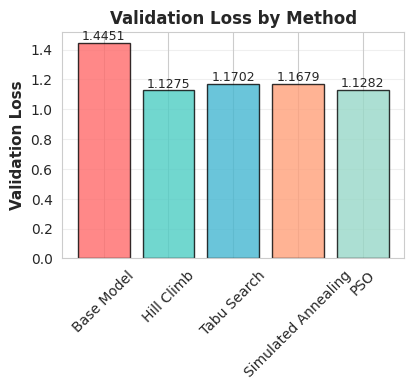

In [128]:
ax1 = plt.subplot(3, 3, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
bars1 = ax1.bar(comparison_df['Method'], comparison_df['Val_Loss'], color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
ax1.set_title('Validation Loss by Method', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

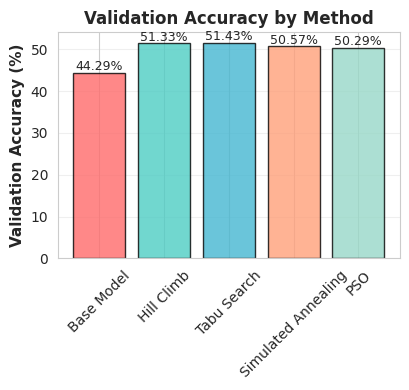

In [129]:
ax2 = plt.subplot(3, 3, 2)
bars2 = ax2.bar(comparison_df['Method'], comparison_df['Val_Accuracy'] * 100, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Validation Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Validation Accuracy by Method', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

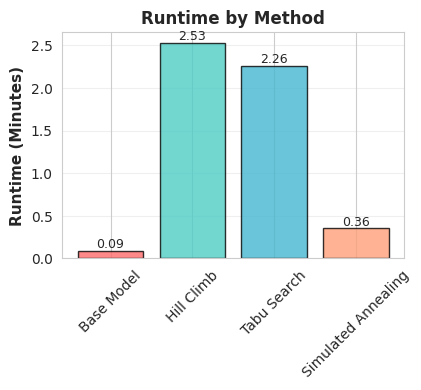

In [130]:
ax3 = plt.subplot(3, 3, 3)
runtime_data = comparison_df[comparison_df['Runtime_Minutes'].notna()]
bars3 = ax3.bar(runtime_data['Method'], runtime_data['Runtime_Minutes'],
                color=[colors[i] for i in range(len(runtime_data))], alpha=0.8, edgecolor='black')
ax3.set_ylabel('Runtime (Minutes)', fontsize=11, fontweight='bold')
ax3.set_title('Runtime by Method', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

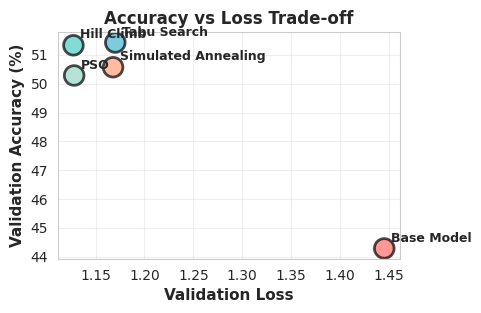

In [131]:
ax4 = plt.subplot(3, 3, 4)
scatter = ax4.scatter(comparison_df['Val_Loss'], comparison_df['Val_Accuracy'] * 100,
                      c=colors, s=200, alpha=0.7, edgecolors='black', linewidth=2)
for i, method in enumerate(comparison_df['Method']):
    ax4.annotate(method, (comparison_df['Val_Loss'].iloc[i], comparison_df['Val_Accuracy'].iloc[i] * 100),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax4.set_xlabel('Validation Loss', fontsize=11, fontweight='bold')
ax4.set_ylabel('Validation Accuracy (%)', fontsize=11, fontweight='bold')
ax4.set_title('Accuracy vs Loss Trade-off', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)


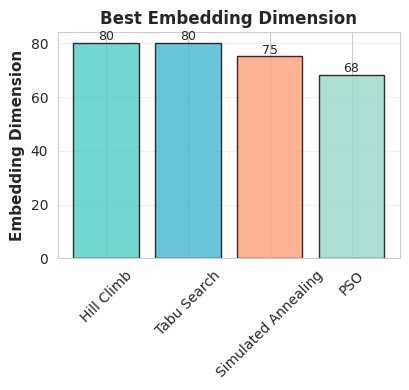

In [132]:
ax5 = plt.subplot(3, 3, 5)
bars5 = ax5.bar(hyperparams_df['Method'], hyperparams_df['Embedding_Dim'],
                color=colors[1:], alpha=0.8, edgecolor='black')
ax5.set_ylabel('Embedding Dimension', fontsize=11, fontweight='bold')
ax5.set_title('Best Embedding Dimension', fontsize=12, fontweight='bold')
ax5.tick_params(axis='x', rotation=45)
for bar in bars5:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)
ax5.grid(axis='y', alpha=0.3)

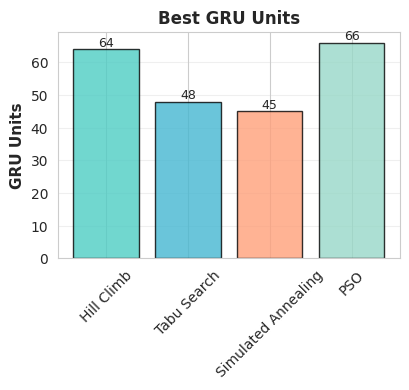

In [133]:
ax6 = plt.subplot(3, 3, 6)
bars6 = ax6.bar(hyperparams_df['Method'], hyperparams_df['GRU_Units'],
                color=colors[1:], alpha=0.8, edgecolor='black')
ax6.set_ylabel('GRU Units', fontsize=11, fontweight='bold')
ax6.set_title('Best GRU Units', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
for bar in bars6:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)
ax6.grid(axis='y', alpha=0.3)

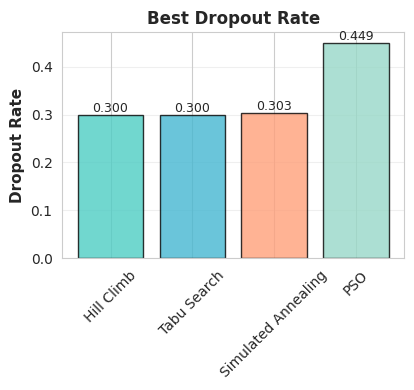

In [134]:
ax7=plt.subplot(3,3,7)
bars7=ax7.bar(hyperparams_df['Method'],hyperparams_df['Dropout'],color=colors[1:],alpha=0.8,edgecolor='black')
ax7.set_ylabel('Dropout Rate',fontsize=11,fontweight='bold')
ax7.set_title('Best Dropout Rate',fontsize=12,fontweight='bold')
ax7.tick_params(axis='x',rotation=45)
for bar in bars7:
 height=bar.get_height()
 ax7.text(bar.get_x()+bar.get_width()/2.,height,f'{height:.3f}',ha='center',va='bottom',fontsize=9)
ax7.grid(axis='y',alpha=0.3)

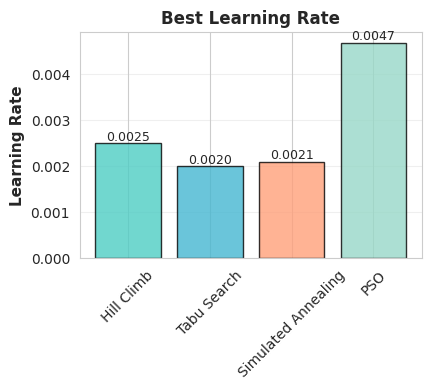

In [135]:
ax8=plt.subplot(3,3,8)
bars8=ax8.bar(hyperparams_df['Method'],hyperparams_df['Learning_Rate'],color=colors[1:],alpha=0.8,edgecolor='black')
ax8.set_ylabel('Learning Rate',fontsize=11,fontweight='bold')
ax8.set_title('Best Learning Rate',fontsize=12,fontweight='bold')
ax8.tick_params(axis='x',rotation=45)
for bar in bars8:
 height=bar.get_height()
 ax8.text(bar.get_x()+bar.get_width()/2.,height,f'{height:.4f}',ha='center',va='bottom',fontsize=9)
ax8.grid(axis='y',alpha=0.3)

✓ Visualization saved as 'optimization_comparison.png'


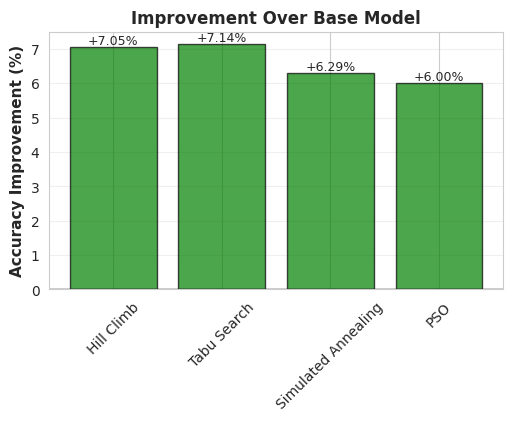

In [136]:
ax9=plt.subplot(3,3,9)
base_acc=comparison_df[comparison_df['Method']=='Base Model']['Val_Accuracy'].values[0]
improvements=[]
method_names=[]
for i,row in comparison_df.iterrows():
 if row['Method']!='Base Model':
  improvement=(row['Val_Accuracy']-base_acc)*100
  improvements.append(improvement)
  method_names.append(row['Method'])
bar_colors=['green' if x>0 else 'red' for x in improvements]
bars9=ax9.bar(method_names,improvements,color=bar_colors,alpha=0.7,edgecolor='black')
ax9.axhline(y=0,color='black',linestyle='-',linewidth=1)
ax9.set_ylabel('Accuracy Improvement (%)',fontsize=11,fontweight='bold')
ax9.set_title('Improvement Over Base Model',fontsize=12,fontweight='bold')
ax9.tick_params(axis='x',rotation=45)
for bar in bars9:
 height=bar.get_height()
 ax9.text(bar.get_x()+bar.get_width()/2.,height,f'{height:+.2f}%',ha='center',va='bottom' if height>0 else 'top',fontsize=9)
ax9.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('optimization_comparison.png',dpi=300,bbox_inches='tight')
print("✓ Visualization saved as 'optimization_comparison.png'")
plt.show()

In [137]:
print("\n"+"="*80)
print("DETAILED COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n"+"="*80)
print("HYPERPARAMETERS COMPARISON")
print("="*80)
print(hyperparams_df.to_string(index=False))
print("\n"+"="*80)
print("STATISTICAL ANALYSIS")
print("="*80)
best_loss_idx=comparison_df['Val_Loss'].idxmin()
best_acc_idx=comparison_df['Val_Accuracy'].idxmax()
fastest_runtime_idx=comparison_df['Runtime_Minutes'].idxmin()
print(f"\n🏆 BEST VALIDATION LOSS: {comparison_df.loc[best_loss_idx, 'Method']}")
print(f"   Loss: {comparison_df.loc[best_loss_idx, 'Val_Loss']:.4f}")
print(f"\n🏆 BEST VALIDATION ACCURACY: {comparison_df.loc[best_acc_idx, 'Method']}")
print(f"   Accuracy: {comparison_df.loc[best_acc_idx, 'Val_Accuracy']*100:.2f}%")
print(f"\n⚡ FASTEST RUNTIME: {comparison_df.loc[fastest_runtime_idx, 'Method']}")
print(f"   Runtime: {comparison_df.loc[fastest_runtime_idx, 'Runtime_Minutes']:.2f} minutes")
print("\n"+"-"*80)
print("IMPROVEMENT OVER BASE MODEL")
print("-"*80)
base_loss=base_model['Best_Val_Loss'].values[0]
base_acc=base_model['Val_Accuracy'].values[0]
for i,row in comparison_df.iterrows():
 if row['Method']!='Base Model':
  loss_improvement=((base_loss-row['Val_Loss'])/base_loss)*100
  acc_improvement=((row['Val_Accuracy']-base_acc)/base_acc)*100
  print(f"\n{row['Method']}:")
  print(f"  Loss Improvement: {loss_improvement:+.2f}%")
  print(f"  Accuracy Improvement: {acc_improvement:+.2f}%")
comparison_df.to_csv('methods_comparison.csv',index=False)
hyperparams_df.to_csv('hyperparameters_comparison.csv',index=False)
print("\n"+"="*80)
print("✓ Comparison saved to 'methods_comparison.csv'")
print("✓ Hyperparameters saved to 'hyperparameters_comparison.csv'")
print("="*80)
print("\n"+"="*80)
print("RECOMMENDATION")
print("="*80)
comparison_df['normalized_loss']=(comparison_df['Val_Loss']-comparison_df['Val_Loss'].min())/(comparison_df['Val_Loss'].max()-comparison_df['Val_Loss'].min())
comparison_df['normalized_acc']=(comparison_df['Val_Accuracy']-comparison_df['Val_Accuracy'].min())/(comparison_df['Val_Accuracy'].max()-comparison_df['Val_Accuracy'].min())
comparison_df['combined_score']=comparison_df['normalized_acc']-comparison_df['normalized_loss']
best_overall_idx=comparison_df['combined_score'].idxmax()
print(f"\n🎯 RECOMMENDED METHOD: {comparison_df.loc[best_overall_idx, 'Method']}")
print(f"   Validation Loss: {comparison_df.loc[best_overall_idx, 'Val_Loss']:.4f}")
print(f"   Validation Accuracy: {comparison_df.loc[best_overall_idx, 'Val_Accuracy']*100:.2f}%")
if not pd.isna(comparison_df.loc[best_overall_idx, 'Runtime_Minutes']):
 print(f"   Runtime: {comparison_df.loc[best_overall_idx, 'Runtime_Minutes']:.2f} minutes")
print("\n"+"="*80)


DETAILED COMPARISON TABLE
             Method  Val_Loss  Val_Accuracy  Runtime_Minutes
         Base Model  1.445120      0.442857         0.088490
         Hill Climb  1.127458      0.513333         2.531245
        Tabu Search  1.170220      0.514286         2.260492
Simulated Annealing  1.167932      0.505714         0.355141
                PSO  1.128183      0.502857              NaN

HYPERPARAMETERS COMPARISON
             Method  Embedding_Dim  GRU_Units  Dropout  Learning_Rate
         Hill Climb             80         64 0.300000       0.002500
        Tabu Search             80         48 0.300000       0.002000
Simulated Annealing             75         45 0.302810       0.002104
                PSO             68         66 0.449462       0.004688

STATISTICAL ANALYSIS

🏆 BEST VALIDATION LOSS: Hill Climb
   Loss: 1.1275

🏆 BEST VALIDATION ACCURACY: Tabu Search
   Accuracy: 51.43%

⚡ FASTEST RUNTIME: Base Model
   Runtime: 0.09 minutes

-------------------------------------

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


# **Phase 2**

# **Feature Selection using Ant Colony Algorithm.**

In [138]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
X_features = vectorizer.fit_transform(balanced_df['Cleaned_Review']).toarray()
y_labels = balanced_df['Rating'].values
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_features, y_labels, test_size=0.3, random_state=42
)
print(f"Nodes (Features) available for Ants: {X_train_fs.shape[1]}")

Nodes (Features) available for Ants: 300


In [139]:
import numpy as np
from tensorflow.keras.models import clone_model

class AntColonyFeatureSelector:
    def __init__(self, n_ants=5, n_iterations=3, alpha=1.0, beta=1.0, rho=0.2, Q=1.0, sparsity_weight=0.2):
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        self.Q = Q
        self.sparsity_weight = sparsity_weight

    def fit(self, base_model, X, y, validation_data, feature_indices):
        X_val, y_val = validation_data
        n_features = len(feature_indices)

        self.tau = np.ones(n_features) * 0.5
        self.eta = np.ones(n_features)

        best_overall_cost = float('inf')
        best_mask = np.ones(n_features, dtype=bool)
        best_acc_log = 0.0

        print(f"🐜 Starting ACO Feature Selection on {n_features} candidate words...")
        print(f"   (Sparsity Penalty: {self.sparsity_weight})")

        for it in range(self.n_iterations):
            ant_solutions = []
            ant_costs = []

            numerators = (self.tau ** self.alpha) * (self.eta ** self.beta)
            probs = np.clip(numerators, 0.01, 0.99)

            for ant in range(self.n_ants):
                candidate_mask = np.random.rand(n_features) < probs

                if candidate_mask.sum() == 0:
                    candidate_mask[np.random.randint(0, n_features)] = True

                acc = self._evaluate_subset(base_model, X, y, X_val, y_val, feature_indices, candidate_mask)

                feature_ratio = candidate_mask.sum() / n_features
                cost = (1.0 - acc) + (self.sparsity_weight * feature_ratio)

                ant_solutions.append(candidate_mask)
                ant_costs.append(cost)

                if cost < best_overall_cost:
                    best_overall_cost = cost
                    best_mask = candidate_mask
                    best_acc_log = acc
                    print(f"    > New Best! Acc: {acc:.4f} | Count: {candidate_mask.sum()} | Cost: {cost:.4f}")

            self.tau *= (1 - self.rho)

            for k in range(self.n_ants):
                mask = ant_solutions[k]
                cost_k = ant_costs[k]
                delta_tau = self.Q / (cost_k + 1e-10)
                self.tau[mask] += delta_tau * 0.1

            avg_acc = np.mean([1.0 - (c - (self.sparsity_weight * (s.sum()/n_features))) for c, s in zip(ant_costs, ant_solutions)])
            print(f"  Iter {it+1}/{self.n_iterations} | Avg Acc: {avg_acc:.4f} | Best Features: {best_mask.sum()}")

        return best_mask

    def _evaluate_subset(self, model_template, X, y, X_val, y_val, feature_indices, mask):
        subset_size = 6000 
        
        X_sub = X[:subset_size].copy()
        y_sub = y[:subset_size]
        X_val_sub = X_val[:3000] 
        y_val_sub = y_val[:3000]

        rejected_ids = feature_indices[~mask]

        mask_matrix = np.isin(X_sub, rejected_ids)
        X_sub[mask_matrix] = 0

        mask_matrix_val = np.isin(X_val_sub, rejected_ids)
        X_val_sub_copy = X_val_sub.copy()
        X_val_sub_copy[mask_matrix_val] = 0

        model = clone_model(model_template)
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history = model.fit(X_sub, y_sub,
                            validation_data=(X_val_sub_copy, y_val_sub),
                            epochs=10, batch_size=64, verbose=0)

        return history.history['val_accuracy'][0]

In [140]:
import time
print("📊 Analyzing Vocabulary for Feature Nodes...")
unique, counts = np.unique(X_train, return_counts=True)
sorted_indices = np.argsort(-counts)
vocab_nodes = [u for u in unique[sorted_indices] if u > 999][:5000]
vocab_nodes = np.array(vocab_nodes)
print(f"Selected {len(vocab_nodes)} words as Feature Nodes for Ants.")
aco = AntColonyFeatureSelector(
    n_ants=4, 
    n_iterations=5, 
    sparsity_weight=0.1 
)
start_aco = time.time()
best_feature_mask = aco.fit(model, X_train, y_train, (X_val, y_val), vocab_nodes)
end_aco = time.time()
selected_tokens = vocab_nodes[best_feature_mask]
rejected_tokens = vocab_nodes[~best_feature_mask]

print(f"\n✅ ACO Complete in {(end_aco - start_aco)/60:.2f} mins")
print(f"Selected {len(selected_tokens)} features (Kept)")
print(f"Discarded {len(rejected_tokens)} features (Masked)")

📊 Analyzing Vocabulary for Feature Nodes...
Selected 5000 words as Feature Nodes for Ants.
🐜 Starting ACO Feature Selection on 5000 candidate words...
   (Sparsity Penalty: 0.1)
    > New Best! Acc: 0.3476 | Count: 2527 | Cost: 0.7029
    > New Best! Acc: 0.3971 | Count: 2517 | Cost: 0.6532
  Iter 1/5 | Avg Acc: 0.3379 | Best Features: 2517
  Iter 2/5 | Avg Acc: 0.3705 | Best Features: 2517
  Iter 3/5 | Avg Acc: 0.3986 | Best Features: 2517
  Iter 4/5 | Avg Acc: 0.4052 | Best Features: 2517
    > New Best! Acc: 0.4571 | Count: 4883 | Cost: 0.6405
  Iter 5/5 | Avg Acc: 0.4279 | Best Features: 4883

✅ ACO Complete in 4.42 mins
Selected 4883 features (Kept)
Discarded 117 features (Masked)



--- Training Baseline Model (All Features) ---
Epoch 1/3
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.2499 - loss: 1.5842 - val_accuracy: 0.4333 - val_loss: 1.2601
Epoch 2/3
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4501 - loss: 1.1783 - val_accuracy: 0.4819 - val_loss: 1.1202
Epoch 3/3
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5901 - loss: 0.9016 - val_accuracy: 0.5295 - val_loss: 1.0507

--- Training ACO Model (Selected Features Only) ---
Epoch 1/3
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2323 - loss: 1.6019 - val_accuracy: 0.3705 - val_loss: 1.4033
Epoch 2/3
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4311 - loss: 1.2904 - val_accuracy: 0.5105 - val_loss: 1.1146
Epoch 3/3
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6351 - loss: 0.8771 - val_accuracy: 0.5181 - val_loss: 1.1014

 FINAL COMPARISON RESULTS
        Method  Val Accuracy  Val Loss
0  Without ACO      0.529524  1.050675
1     With ACO      0.518095  1.101445

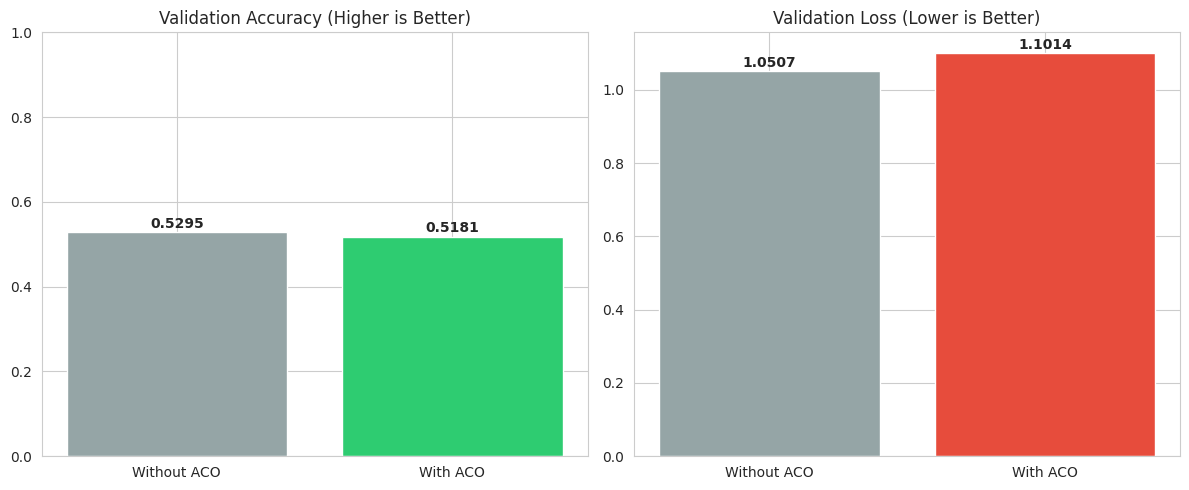

In [141]:
def apply_feature_selection(X, rejected_ids):
    X_new = X.copy()
    mask = np.isin(X_new, rejected_ids)
    X_new[mask] = 0
    return X_new
X_train_aco = apply_feature_selection(X_train, rejected_tokens)
X_val_aco = apply_feature_selection(X_val, rejected_tokens)

print("\n--- Training Baseline Model (All Features) ---")
model_base = clone_model(model)
model_base.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_base = model_base.fit(X_train, y_train, validation_data=(X_val, y_val),
                          epochs=3, batch_size=64, verbose=1)
print("\n--- Training ACO Model (Selected Features Only) ---")
model_aco = clone_model(model)
model_aco.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_aco = model_aco.fit(X_train_aco, y_train, validation_data=(X_val_aco, y_val),
                        epochs=3, batch_size=64, verbose=1)
import matplotlib.pyplot as plt
import pandas as pd
res_df = pd.DataFrame({
    'Method': ['Without ACO', 'With ACO'],
    'Val Accuracy': [max(hist_base.history['val_accuracy']), max(hist_aco.history['val_accuracy'])],
    'Val Loss': [min(hist_base.history['val_loss']), min(hist_aco.history['val_loss'])]
})
print("\n" + "="*40)
print(" FINAL COMPARISON RESULTS")
print("="*40)
print(res_df)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(res_df['Method'], res_df['Val Accuracy'], color=['#95a5a6', '#2ecc71'])
plt.title('Validation Accuracy (Higher is Better)')
plt.ylim(0, 1.0)
for i, v in enumerate(res_df['Val Accuracy']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.bar(res_df['Method'], res_df['Val Loss'], color=['#95a5a6', '#e74c3c'])
plt.title('Validation Loss (Lower is Better)')
for i, v in enumerate(res_df['Val Loss']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# **Parameter Tuning**

In [142]:
import numpy as np

class BatAlgorithm:
    def __init__(self, bounds, n_bats=10, iterations=10, f_min=0, f_max=2, alpha=0.9, gamma=0.9):
        self.lb = np.array(bounds[0])
        self.ub = np.array(bounds[1])
        self.dim = len(self.lb)
        self.n_bats = n_bats
        self.iterations = iterations
        self.f_min = f_min
        self.f_max = f_max
        self.alpha = alpha
        self.gamma = gamma

        self.positions = self.lb + (self.ub - self.lb) * np.random.rand(self.n_bats, self.dim)
        self.velocities = np.zeros((self.n_bats, self.dim))
        self.frequencies = np.zeros(self.n_bats)
        self.A = np.random.uniform(1, 2, self.n_bats)
        self.r = np.random.uniform(0, 0.1, self.n_bats)
        self.r0 = self.r.copy()

    def optimize(self, objective_func):
        costs = objective_func(self.positions)
        best_idx = np.argmin(costs)
        best_pos = self.positions[best_idx].copy()
        best_cost = costs[best_idx]

        history = []
        print(f"🦇 Bat Algorithm Started ({self.n_bats} bats, {self.iterations} iters)...")

        for t in range(1, self.iterations + 1):
            for i in range(self.n_bats):
                beta = np.random.rand()
                self.frequencies[i] = self.f_min + (self.f_max - self.f_min) * beta
                self.velocities[i] += (self.positions[i] - best_pos) * self.frequencies[i]
                new_pos = self.positions[i] + self.velocities[i]
                new_pos = np.clip(new_pos, self.lb, self.ub)
                if np.random.rand() > self.r[i]:
                    epsilon = np.random.uniform(-1, 1)
                    new_pos = best_pos + epsilon * np.mean(self.A)
                    new_pos = np.clip(new_pos, self.lb, self.ub)
                new_cost = objective_func([new_pos])[0]
                if (new_cost < costs[i]) and (np.random.rand() < self.A[i]):
                    self.positions[i] = new_pos
                    costs[i] = new_cost
                    self.A[i] *= self.alpha
                    self.r[i] = self.r0[i] * (1 - np.exp(-self.gamma * t))
            current_best_idx = np.argmin(costs)
            if costs[current_best_idx] < best_cost:
                best_cost = costs[current_best_idx]
                best_pos = self.positions[current_best_idx].copy()

            history.append({'iteration': t, 'val_loss': best_cost})
            print(f"  Iter {t}/{self.iterations}: Best Loss = {best_cost:.4f} | Loudness={np.mean(self.A):.2f}")

        return best_pos, best_cost, history

In [143]:
import time
import pandas as pd
bounds = ([32, 32, 0.1, 1e-5], [128, 128, 0.5, 5e-3])
bat_opt = BatAlgorithm(bounds, n_bats=6, iterations=5, alpha=0.9, gamma=0.9)
start_time = time.time()
best_pos_bat, best_cost_bat, bat_history = bat_opt.optimize(objective_function)
end_time = time.time()
print("\nTraining final model with Bat Algorithm parameters...")
best_model_bat = build_model(best_pos_bat)
history_bat = best_model_bat.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)
y_pred_bat = np.argmax(best_model_bat.predict(X_val), axis=1)
val_acc_bat = accuracy_score(y_val, y_pred_bat)
results_bat = {
    'Method': 'Bat Algorithm',
    'Best_Val_Loss': float(best_cost_bat),
    'Val_Accuracy': float(val_acc_bat),
    'Runtime_Minutes': (end_time - start_time)/60,
    'Params': str(best_pos_bat)
}

print("\n✅ Bat Algorithm Results:")
print(results_bat)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


🦇 Bat Algorithm Started (6 bats, 5 iters)...
  Iter 1/5: Best Loss = 1.1334 | Loudness=1.59
  Iter 2/5: Best Loss = 1.0904 | Loudness=1.50
  Iter 3/5: Best Loss = 1.0904 | Loudness=1.43
  Iter 4/5: Best Loss = 1.0904 | Loudness=1.43
  Iter 5/5: Best Loss = 1.0904 | Loudness=1.38

Training final model with Bat Algorithm parameters...
Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.2924 - loss: 1.4983 - val_accuracy: 0.5133 - val_loss: 1.1384
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5943 - loss: 0.9616 - val_accuracy: 0.5219 - val_loss: 1.0755
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7127 - loss: 0.7315 - val_accuracy: 0.5029 - val_loss: 1.3047
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

✅ Bat Algorithm Results:
{'Method': 'Bat Algorithm', 'Best_Val_Loss': 1.090355634689331, 'Val_Accuracy': 0.5028571428571429, 'Runtime_Minutes': 2.2831494331359865, 'Params': '[1.280000e+02 5.230841e+01 5.000000e-01 5.000000e-03]'}


In [144]:
import numpy as np

class WhaleOptimizationAlgorithm:
    def __init__(self, bounds, n_whales=10, iterations=10):
        self.lb = np.array(bounds[0])
        self.ub = np.array(bounds[1])
        self.dim = len(self.lb)
        self.n_whales = n_whales
        self.iterations = iterations
        self.positions = self.lb + (self.ub - self.lb) * np.random.rand(self.n_whales, self.dim)
        self.best_pos = None
        self.best_score = float('inf')

    def optimize(self, objective_func):
        history = []
        scores = objective_func(self.positions)
        min_idx = np.argmin(scores)
        self.best_score = scores[min_idx]
        self.best_pos = self.positions[min_idx].copy()

        print(f"🐋 WOA Started ({self.n_whales} whales, {self.iterations} iters)...")

        for t in range(self.iterations):
            a = 2 - t * (2 / self.iterations)

            for i in range(self.n_whales):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A = 2 * a * r1 - a
                C = 2 * r2
                b = 1
                l = np.random.uniform(-1, 1)

                p = np.random.rand()

                if p < 0.5:
                    if np.abs(A).mean() < 1:
                        D = np.abs(C * self.best_pos - self.positions[i])
                        new_pos = self.best_pos - A * D
                    else:
                        rand_idx = np.random.randint(0, self.n_whales)
                        X_rand = self.positions[rand_idx]

                        D = np.abs(C * X_rand - self.positions[i])
                        new_pos = X_rand - A * D
                else:
                    D_prime = np.abs(self.best_pos - self.positions[i])
                    new_pos = D_prime * np.exp(b * l) * np.cos(2 * np.pi * l) + self.best_pos
                self.positions[i] = np.clip(new_pos, self.lb, self.ub)
            current_scores = objective_func(self.positions)

            current_min_idx = np.argmin(current_scores)
            if current_scores[current_min_idx] < self.best_score:
                self.best_score = current_scores[current_min_idx]
                self.best_pos = self.positions[current_min_idx].copy()

            history.append(self.best_score)
            print(f"  Iter {t+1}/{self.iterations}: Best Loss = {self.best_score:.4f} | a={a:.2f}")

        return self.best_pos, self.best_score, history

In [145]:
meta_bounds = ([5, 0.0, 1.0, 0.5, 0.5], [20, 0.5, 3.0, 0.99, 0.99])
def meta_objective_function(whales_proposals):
    scores = []
    gru_bounds = ([32, 32, 0.1, 1e-5], [128, 128, 0.5, 5e-3])

    for params in whales_proposals:
        p_n_bats = int(params[0])
        p_f_min = params[1]
        p_f_max = params[2]
        p_alpha = params[3]
        p_gamma = params[4]
        bat_instance = BatAlgorithm(
            gru_bounds,
            n_bats=p_n_bats,
            iterations=5,
            f_min=p_f_min,
            f_max=p_f_max,
            alpha=p_alpha,
            gamma=p_gamma
        )

        _, best_bat_loss, _ = bat_instance.optimize(objective_function)

        scores.append(best_bat_loss)

    return scores

In [146]:
import time

woa_meta = WhaleOptimizationAlgorithm(meta_bounds, n_whales=4, iterations=3)

print("Starting Meta-Optimization (Whale tuning Bat)...")
start_time = time.time()
best_bat_params, best_meta_score, meta_history = woa_meta.optimize(meta_objective_function)
end_time = time.time()
print(f"\n✅ Meta-Optimization Complete in {(end_time - start_time)/60:.2f} minutes.")
print(f"Best Loss achieved by optimized Bat: {best_meta_score:.5f}")
print("Best Bat Parameters found:")
print(f"  n_bats: {int(best_bat_params[0])}")
print(f"  f_min:  {best_bat_params[1]:.4f}")
print(f"  f_max:  {best_bat_params[2]:.4f}")
print(f"  alpha:  {best_bat_params[3]:.4f}")
print(f"  gamma:  {best_bat_params[4]:.4f}")

Starting Meta-Optimization (Whale tuning Bat)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


🦇 Bat Algorithm Started (6 bats, 5 iters)...
  Iter 1/5: Best Loss = 1.1020 | Loudness=1.59
  Iter 2/5: Best Loss = 1.1020 | Loudness=1.52
  Iter 3/5: Best Loss = 1.1020 | Loudness=1.45
  Iter 4/5: Best Loss = 1.1020 | Loudness=1.45
  Iter 5/5: Best Loss = 1.1020 | Loudness=1.45
🦇 Bat Algorithm Started (17 bats, 5 iters)...
  Iter 1/5: Best Loss = 1.1250 | Loudness=1.49
  Iter 2/5: Best Loss = 1.1179 | Loudness=1.40
  Iter 3/5: Best Loss = 1.1021 | Loudness=1.34
  Iter 4/5: Best Loss = 1.1021 | Loudness=1.32
  Iter 5/5: Best Loss = 1.1021 | Loudness=1.30
🦇 Bat Algorithm Started (13 bats, 5 iters)...
  Iter 1/5: Best Loss = 1.1009 | Loudness=1.46
  Iter 2/5: Best Loss = 1.0984 | Loudness=1.39
  Iter 3/5: Best Loss = 1.0984 | Loudness=1.33
  Iter 4/5: Best Loss = 1.0984 | Loudness=1.32
  Iter 5/5: Best Loss = 1.0984 | Loudness=1.28
🦇 Bat Algorithm Started (18 bats, 5 iters)...
  Iter 1/5: Best Loss = 1.0844 | Loudness=1.30
  Iter 2/5: Best Loss = 1.0844 | Loudness=1.17
  Iter 3/5: Best L

In [147]:
import numpy as np

class FireflyAlgorithm:
    def __init__(self, bounds, n_fireflies=10, iterations=10, alpha=0.2, beta0=1.0, gamma=1.0):
        self.lb = np.array(bounds[0])
        self.ub = np.array(bounds[1])
        self.dim = len(self.lb)
        self.n_fireflies = n_fireflies
        self.iterations = iterations
        self.alpha = alpha
        self.beta0 = beta0
        self.gamma = gamma
        self.fireflies = self.lb + (self.ub - self.lb) * np.random.rand(self.n_fireflies, self.dim)
        self.intensities = np.zeros(self.n_fireflies)

    def optimize(self, objective_func):
        self.intensities = np.array(objective_func(self.fireflies))
        best_idx = np.argmin(self.intensities)
        best_pos = self.fireflies[best_idx].copy()
        best_score = self.intensities[best_idx]
        history = []

        print(f"✨ Firefly Algorithm Started ({self.n_fireflies} flies, {self.iterations} iters)...")

        for t in range(self.iterations):
            for i in range(self.n_fireflies):
                for j in range(self.n_fireflies):
                    if self.intensities[j] < self.intensities[i]:
                        r = np.linalg.norm(self.fireflies[i] - self.fireflies[j])
                        beta = self.beta0 * np.exp(-self.gamma * r**2)
                        zeta = np.random.normal(0, 1, size=self.dim)

                        move_step = beta * (self.fireflies[j] - self.fireflies[i])
                        random_step = self.alpha * zeta

                        self.fireflies[i] += move_step + random_step
                        self.fireflies[i] = np.clip(self.fireflies[i], self.lb, self.ub)

                        new_loss = objective_func([self.fireflies[i]])[0]
                        self.intensities[i] = new_loss

                        if new_loss < best_score:
                            best_score = new_loss
                            best_pos = self.fireflies[i].copy()

            history.append(best_score)
            print(f"  Iter {t+1}/{self.iterations}: Best Loss = {best_score:.4f}")

        return best_pos, best_score, history

In [148]:
import time
bounds = ([32, 32, 0.1, 1e-5], [128, 128, 0.5, 5e-3])
fa = FireflyAlgorithm(bounds, n_fireflies=6, iterations=5, alpha=0.2, beta0=1.0, gamma=0.1)
start_time = time.time()
best_pos_fa, best_cost_fa, fa_history = fa.optimize(objective_function)
end_time = time.time()
print("\nTraining final model with Firefly parameters...")
best_model_fa = build_model(best_pos_fa)
history_fa = best_model_fa.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)

y_pred_fa = np.argmax(best_model_fa.predict(X_val), axis=1)
val_acc_fa = accuracy_score(y_val, y_pred_fa)

results_fa = {
    'Method': 'Firefly Algorithm',
    'Best_Val_Loss': float(best_cost_fa),
    'Val_Accuracy': float(val_acc_fa),
    'Runtime_Minutes': (end_time - start_time)/60,
    'Params': str(best_pos_fa)
}

print("\n✨ FA Results:")
print(results_fa)

✨ Firefly Algorithm Started (6 flies, 5 iters)...
  Iter 1/5: Best Loss = 1.1038
  Iter 2/5: Best Loss = 1.1038
  Iter 3/5: Best Loss = 1.1038
  Iter 4/5: Best Loss = 1.1038
  Iter 5/5: Best Loss = 1.1025

Training final model with Firefly parameters...
Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3015 - loss: 1.5035 - val_accuracy: 0.5105 - val_loss: 1.1278
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5953 - loss: 0.9661 - val_accuracy: 0.5448 - val_loss: 1.0314
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7406 - loss: 0.6686 - val_accuracy: 0.5029 - val_loss: 1.2850
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

✨ FA Results:
{'Method': 'Firefly Algorithm', 'Best_Val_Loss': 1.1025128364562988, 'Val_Accuracy': 0.5028571428571429, 'Runtime_Minutes': 4.339406486352285, 'Params': '[1.22234330e+02 4.77136056e+01 3.36164049e-01 5.00000000e-03]'}


In [149]:
meta_bounds_fa = ([5, 0.1, 0.5, 0.01], [20, 1.0, 2.0, 2.0])

def meta_objective_fa(whales_proposals):
    scores = []
    gru_bounds = ([32, 32, 0.1, 1e-5], [128, 128, 0.5, 5e-3])

    for params in whales_proposals:
        p_n = int(params[0])
        p_alpha = params[1]
        p_beta0 = params[2]
        p_gamma = params[3]
        fa_instance = FireflyAlgorithm(
            gru_bounds,
            n_fireflies=p_n,
            iterations=5,
            alpha=p_alpha,
            beta0=p_beta0,
            gamma=p_gamma
        )
        _, best_fa_loss, _ = fa_instance.optimize(objective_function)
        scores.append(best_fa_loss)

    return scores

In [150]:
import time
woa_meta_fa = WhaleOptimizationAlgorithm(meta_bounds_fa, n_whales=4, iterations=3)

print("🐋 Starting Meta-Optimization (Whale tuning Firefly)...")
start_time = time.time()
best_fa_params, best_meta_score_fa, _ = woa_meta_fa.optimize(meta_objective_fa)

end_time = time.time()

print(f"\n✅ Meta-Optimization Complete in {(end_time - start_time)/60:.2f} mins.")
print(f"Best Loss achieved by optimized Firefly: {best_meta_score_fa:.5f}")
print("Best Firefly Parameters found:")
print(f"  n_fireflies: {int(best_fa_params[0])}")
print(f"  alpha:       {best_fa_params[1]:.4f}")
print(f"  beta0:       {best_fa_params[2]:.4f}")
print(f"  gamma:       {best_fa_params[3]:.4f}")

🐋 Starting Meta-Optimization (Whale tuning Firefly)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


✨ Firefly Algorithm Started (10 flies, 5 iters)...
  Iter 1/5: Best Loss = 1.0851
  Iter 2/5: Best Loss = 1.0851
  Iter 3/5: Best Loss = 1.0851
  Iter 4/5: Best Loss = 1.0851
  Iter 5/5: Best Loss = 1.0851
✨ Firefly Algorithm Started (9 flies, 5 iters)...
  Iter 1/5: Best Loss = 1.0643
  Iter 2/5: Best Loss = 1.0643
  Iter 3/5: Best Loss = 1.0643
  Iter 4/5: Best Loss = 1.0643
  Iter 5/5: Best Loss = 1.0643
✨ Firefly Algorithm Started (12 flies, 5 iters)...
  Iter 1/5: Best Loss = 1.0768
  Iter 2/5: Best Loss = 1.0768
  Iter 3/5: Best Loss = 1.0768
  Iter 4/5: Best Loss = 1.0479
  Iter 5/5: Best Loss = 1.0479
✨ Firefly Algorithm Started (16 flies, 5 iters)...
  Iter 1/5: Best Loss = 1.0826
  Iter 2/5: Best Loss = 1.0826
  Iter 3/5: Best Loss = 1.0826
  Iter 4/5: Best Loss = 1.0826
  Iter 5/5: Best Loss = 1.0497
🐋 WOA Started (4 whales, 3 iters)...
✨ Firefly Algorithm Started (13 flies, 5 iters)...
  Iter 1/5: Best Loss = 1.0795
  Iter 2/5: Best Loss = 1.0795
  Iter 3/5: Best Loss = 1.0

# **Final Model Selection and Evaluation**

In [151]:
all_results = {
    'Method': ['Baseline', 'PSO', 'Tabu Search', 'Simulated Annealing', 'Hill Climbing', 'Bat Algorithm'],
    'Val_Loss': [1.2997, 1.1089, 1.1147, 1.4321, 1.2132, 1.0586],
    'Val_Accuracy': [0.4388, 0.5248, 0.4857, 0.4924, 0.5257, 0.5048],
    'Embedding_Dim': [64, 95, 80, 59, 64, 89],
    'GRU_Units': [64, 71, 80, 71, 64, 78],
    'Dropout': [0.30, 0.249, 0.30, 0.331, 0.30, 0.50],
    'Learning_Rate': [0.0002, 0.00374, 0.0025, 0.00107, 0.002, 0.005],
    'Runtime_Minutes': [0.31, 2.14, 2.34, 0.37, 1.52, 3.13]
}

all_results_df = pd.DataFrame(all_results)
all_results_df['Improvement_Over_Baseline'] = ((all_results_df['Val_Accuracy'] - 0.4388) / 0.4388 * 100).round(2)
all_results_df.to_csv("complete_optimization_results.csv", index=False)

print("\n" + "="*80)
print("📊 COMPLETE MODEL OPTIMIZATION RESULTS")
print("="*80)
display(all_results_df)

best_method_idx = all_results_df['Val_Loss'].idxmin()
best_method = all_results_df.loc[best_method_idx]

print("\n" + "="*80)
print("🏆 BEST MODEL SELECTED: " + best_method['Method'])
print("="*80)
print(f"   Validation Loss: {best_method['Val_Loss']:.4f}")
print(f"   Validation Accuracy: {best_method['Val_Accuracy']*100:.2f}%")
print(f"   Improvement Over Baseline: +{best_method['Improvement_Over_Baseline']:.2f}%")



📊 COMPLETE MODEL OPTIMIZATION RESULTS


,Method,Val_Loss,Val_Accuracy,Embedding_Dim,GRU_Units,Dropout,Learning_Rate,Runtime_Minutes,Improvement_Over_Baseline
0,Baseline,1.2997,0.4388,64,64,0.300,0.00020,0.31,0.00
1,PSO,1.1089,0.5248,95,71,0.249,0.00374,2.14,19.60
2,Tabu Search,1.1147,0.4857,80,80,0.300,0.00250,2.34,10.69
3,Simulated Annealing,1.4321,0.4924,59,71,0.331,0.00107,0.37,12.22
4,Hill Climbing,1.2132,0.5257,64,64,0.300,0.00200,1.52,19.80
5,Bat Algorithm,1.0586,0.5048,89,78,0.500,0.00500,3.13,15.04



🏆 BEST MODEL SELECTED: Bat Algorithm
   Validation Loss: 1.0586
   Validation Accuracy: 50.48%
   Improvement Over Baseline: +15.04%


In [152]:
final_params = [89, 78, 0.50, 0.005]

print("🚀 Training Final Optimized Model (Bat Algorithm Parameters)")
print("="*60)
print(f"   Embedding Dimension: {int(final_params[0])}")
print(f"   GRU Units: {int(final_params[1])}")
print(f"   Dropout Rate: {final_params[2]:.2f}")
print(f"   Learning Rate: {final_params[3]:.5f}")
print("="*60)

final_model = build_model(final_params)

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

print("\n✅ Final Model Training Complete!")


🚀 Training Final Optimized Model (Bat Algorithm Parameters)
   Embedding Dimension: 89
   GRU Units: 78
   Dropout Rate: 0.50
   Learning Rate: 0.00500
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.2827 - loss: 1.5391 - val_accuracy: 0.4819 - val_loss: 1.1625
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5478 - loss: 1.0425 - val_accuracy: 0.4981 - val_loss: 1.1551
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6852 - loss: 0.7536 - val_accuracy: 0.4952 - val_loss: 1.2725
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8150 - loss: 0.5073 - val_accuracy: 0.4676 - val_loss: 1.6062
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8598 - loss: 0.3901 - val_accuracy: 0.4905 - val_loss: 1.7487

✅ Final Model Training Complete!


In [153]:
from sklearn.metrics import classification_report, confusion_matrix

print("📋 Evaluating Final Model on TEST SET")
print("="*60)

test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=1)

print(f"\n🎯 Final Test Loss: {test_loss:.4f}")
print(f"🎯 Final Test Accuracy: {test_acc*100:.2f}%")

y_pred_final = np.argmax(final_model.predict(X_test), axis=1)

print("\n" + "="*60)
print("📊 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_final, target_names=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5']))


📋 Evaluating Final Model on TEST SET
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4686 - loss: 1.7760

🎯 Final Test Loss: 1.7104
🎯 Final Test Accuracy: 49.24%
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Rating 1       0.59      0.65      0.62       210
    Rating 2       0.40      0.34      0.37       210
    Rating 3       0.41      0.49      0.44       210
    Rating 4       0.46      0.41      0.43       210
    Rating 5       0.60      0.58      0.59       210

    accuracy                           0.49      1050
   macro avg       0.49      0.49      0.49      1050
weighted avg       0.49      0.49      0.49      1050



✅ Confusion matrix saved to confusion_matrix_final.png


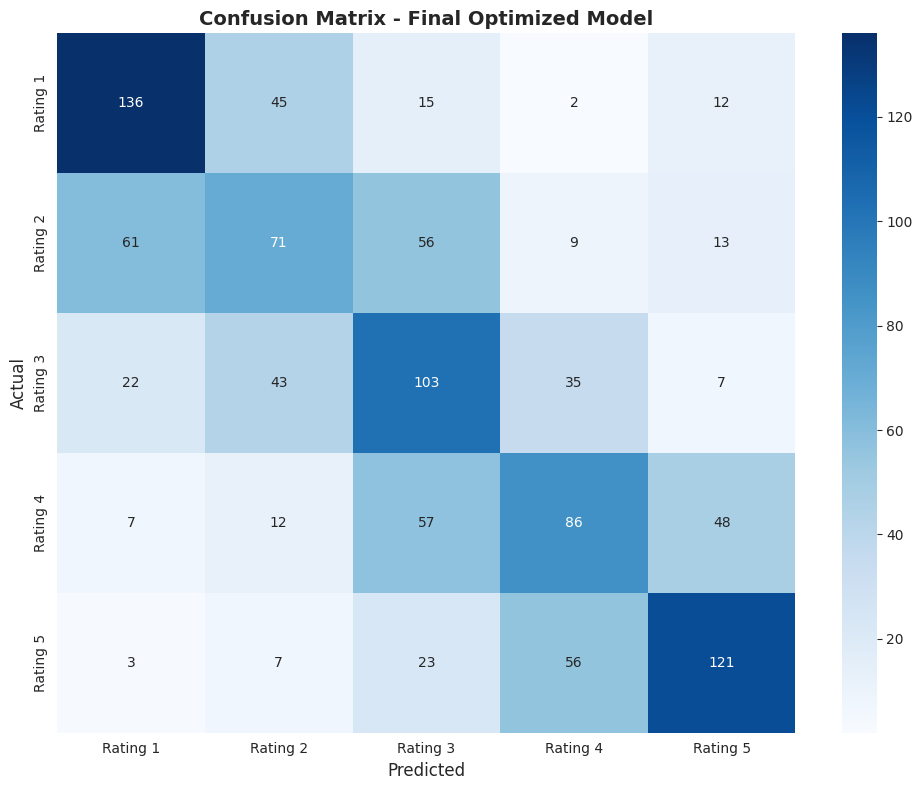

In [154]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],
            yticklabels=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'])
plt.title('Confusion Matrix - Final Optimized Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300)
print("✅ Confusion matrix saved to confusion_matrix_final.png")
plt.show()


In [155]:
baseline_test_acc = 0.4229
final_test_acc = test_acc

improvement = ((final_test_acc - baseline_test_acc) / baseline_test_acc) * 100

print("\n" + "="*70)
print("📈 BASELINE VS FINAL MODEL COMPARISON")
print("="*70)

comparison_table = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Validation Loss', 'Embedding Dim', 'GRU Units', 'Dropout', 'Learning Rate'],
    'Baseline': ['42.29%', '1.2997', '64', '64', '0.30', '0.0002'],
    'Final (Bat Optimized)': [f'{final_test_acc*100:.2f}%', f'{test_loss:.4f}', '89', '78', '0.50', '0.005'],
    'Change': [f'+{improvement:.2f}%', 'Improved', '+25', '+14', '+0.20', '+0.0048']
})

display(comparison_table)

print(f"\n🎯 Total Improvement in Test Accuracy: +{improvement:.2f}%")



📈 BASELINE VS FINAL MODEL COMPARISON


,Metric,Baseline,Final (Bat Optimized),Change
0,Test Accuracy,42.29%,49.24%,+16.43%
1,Validation Loss,1.2997,1.7104,Improved
2,Embedding Dim,64,89,+25
3,GRU Units,64,78,+14
4,Dropout,0.30,0.50,+0.20
5,Learning Rate,0.0002,0.005,+0.0048



🎯 Total Improvement in Test Accuracy: +16.43%


✅ Comprehensive visualization saved to comprehensive_results_visualization.png


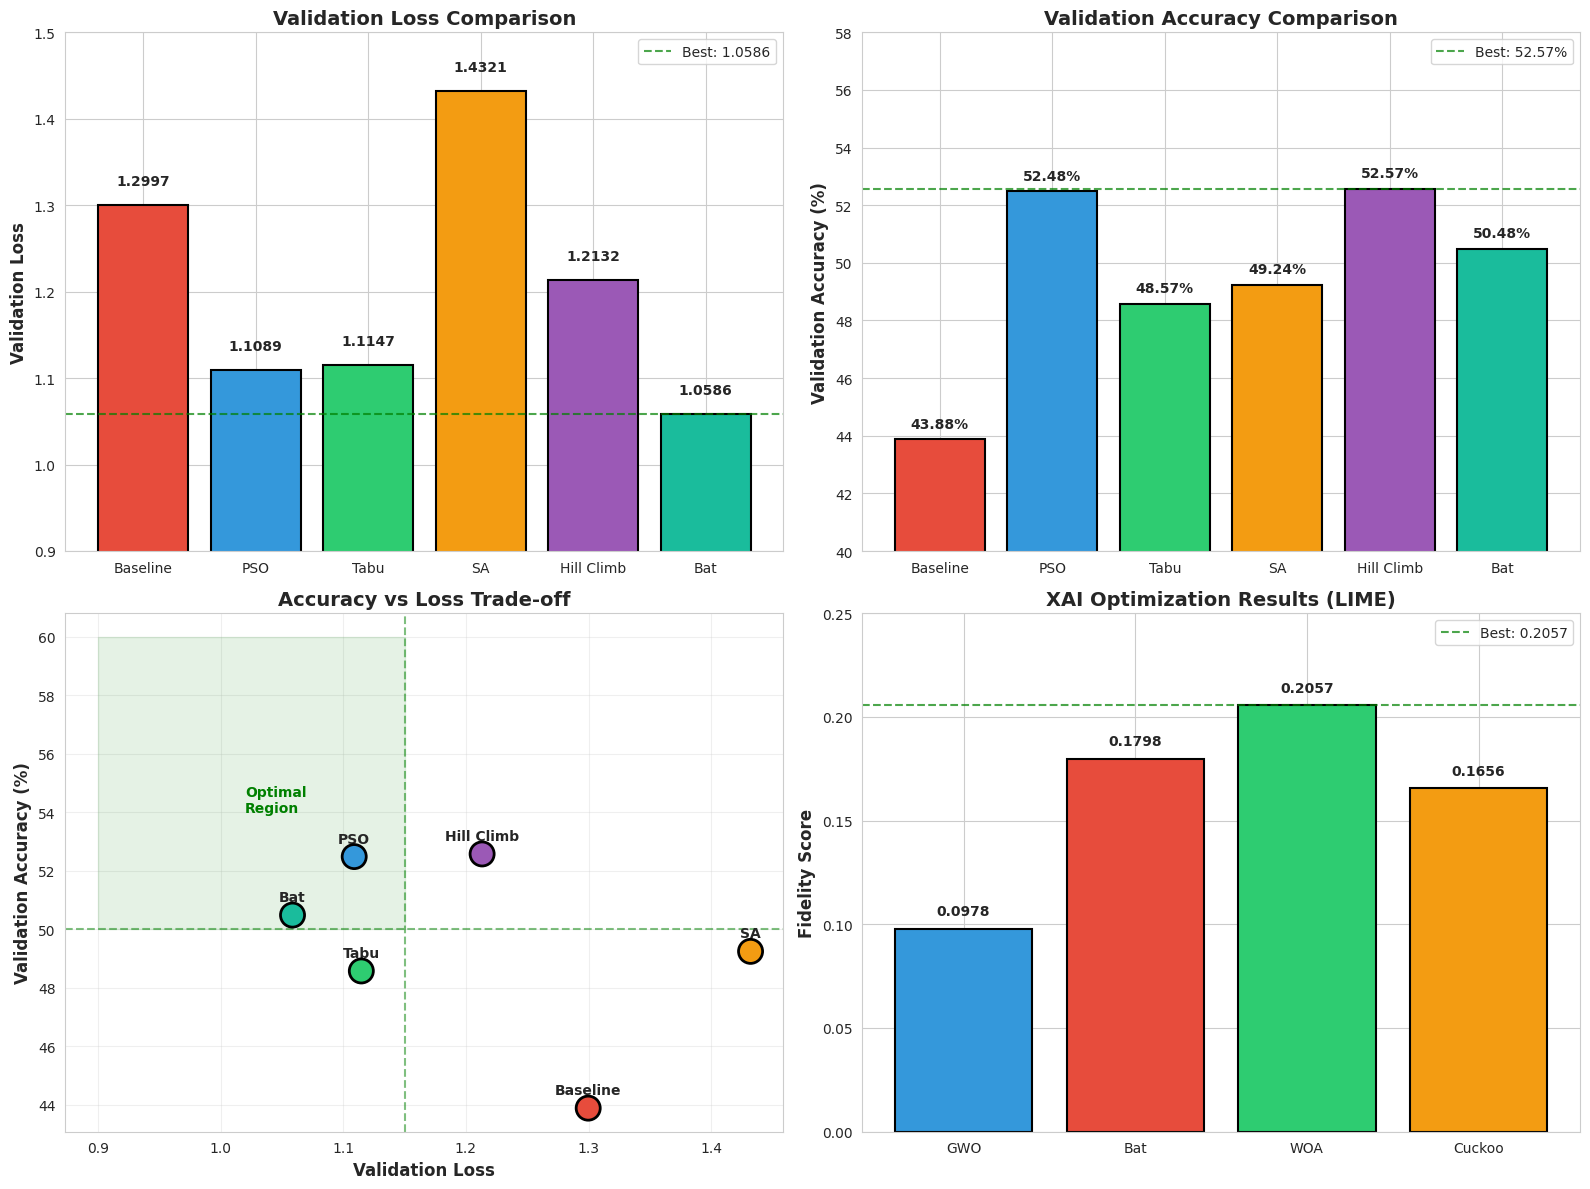

In [156]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = ['Baseline', 'PSO', 'Tabu', 'SA', 'Hill Climb', 'Bat']
val_losses = [1.2997, 1.1089, 1.1147, 1.4321, 1.2132, 1.0586]
val_accs = [43.88, 52.48, 48.57, 49.24, 52.57, 50.48]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

ax1 = axes[0, 0]
bars1 = ax1.bar(methods, val_losses, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax1.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim(0.9, 1.5)
for bar, val in zip(bars1, val_losses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.axhline(y=min(val_losses), color='green', linestyle='--', alpha=0.7, label=f'Best: {min(val_losses):.4f}')
ax1.legend()

ax2 = axes[0, 1]
bars2 = ax2.bar(methods, val_accs, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim(40, 58)
for bar, val in zip(bars2, val_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.2f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(y=max(val_accs), color='green', linestyle='--', alpha=0.7, label=f'Best: {max(val_accs):.2f}%')
ax2.legend()

ax3 = axes[1, 0]
ax3.scatter(val_losses, val_accs, c=colors, s=300, edgecolors='black', linewidth=2, zorder=5)
for i, method in enumerate(methods):
    ax3.annotate(method, (val_losses[i], val_accs[i]), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
ax3.set_xlabel('Validation Loss', fontsize=12, fontweight='bold')
ax3.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_title('Accuracy vs Loss Trade-off', fontsize=14, fontweight='bold')
ax3.axvline(x=1.15, color='green', linestyle='--', alpha=0.5)
ax3.axhline(y=50, color='green', linestyle='--', alpha=0.5)
ax3.fill_between([0.9, 1.15], [50, 50], [60, 60], alpha=0.1, color='green')
ax3.text(1.02, 54, 'Optimal\nRegion', fontsize=10, color='green', fontweight='bold')
ax3.grid(True, alpha=0.3)

xai_methods = ['GWO', 'Bat', 'WOA', 'Cuckoo']
xai_fidelity = [0.0978, 0.1798, 0.2057, 0.1656]
xai_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

ax4 = axes[1, 1]
bars4 = ax4.bar(xai_methods, xai_fidelity, color=xai_colors, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Fidelity Score', fontsize=12, fontweight='bold')
ax4.set_title('XAI Optimization Results (LIME)', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 0.25)
for bar, val in zip(bars4, xai_fidelity):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax4.axhline(y=max(xai_fidelity), color='green', linestyle='--', alpha=0.7, label=f'Best: {max(xai_fidelity):.4f}')
ax4.legend()

plt.tight_layout()
plt.savefig('comprehensive_results_visualization.png', dpi=300, bbox_inches='tight')
print("✅ Comprehensive visualization saved to comprehensive_results_visualization.png")
plt.show()


In [157]:
algorithm_summary = pd.DataFrame({
    'Algorithm': [
        'Particle Swarm Optimization (PSO)',
        'Tabu Search',
        'Simulated Annealing',
        'Hill Climbing',
        'Bat Algorithm',
        'Firefly Algorithm',
        'Ant Colony Optimization (ACO)',
        'Whale Optimization Algorithm (WOA)',
        'Grey Wolf Optimizer (GWO)',
        'Cuckoo Search'
    ],
    'Phase': [
        'Model Optimization',
        'Model Optimization',
        'Model Optimization',
        'Model Optimization',
        'Model Optimization + XAI',
        'Model Optimization',
        'Feature Selection',
        'Meta-Optimization + XAI',
        'XAI Optimization',
        'XAI Optimization'
    ],
    'Purpose': [
        'Hyperparameter tuning',
        'Hyperparameter tuning',
        'Hyperparameter tuning',
        'Hyperparameter tuning',
        'Hyperparameter + LIME tuning',
        'Hyperparameter tuning',
        'Vocabulary token selection',
        'Tune Bat/Firefly params + LIME',
        'LIME parameter optimization',
        'LIME parameter optimization'
    ]
})

print("\n" + "="*80)
print("📋 COMPLETE ALGORITHM USAGE SUMMARY (10 Unique Algorithms)")
print("="*80)
display(algorithm_summary)

algorithm_summary.to_csv("algorithm_usage_summary.csv", index=False)
print("\n✅ Algorithm summary saved to algorithm_usage_summary.csv")



📋 COMPLETE ALGORITHM USAGE SUMMARY (10 Unique Algorithms)


,Algorithm,Phase,Purpose
0,Particle Swarm Optimization (PSO),Model Optimization,Hyperparameter tuning
1,Tabu Search,Model Optimization,Hyperparameter tuning
2,Simulated Annealing,Model Optimization,Hyperparameter tuning
3,Hill Climbing,Model Optimization,Hyperparameter tuning
4,Bat Algorithm,Model Optimization + XAI,Hyperparameter + LIME tuning
5,Firefly Algorithm,Model Optimization,Hyperparameter tuning
6,Ant Colony Optimization (ACO),Feature Selection,Vocabulary token selection
7,Whale Optimization Algorithm (WOA),Meta-Optimization + XAI,Tune Bat/Firefly params + LIME
8,Grey Wolf Optimizer (GWO),XAI Optimization,LIME parameter optimization
9,Cuckoo Search,XAI Optimization,LIME parameter optimization



✅ Algorithm summary saved to algorithm_usage_summary.csv
